In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [2]:
sigma = 1.0
epsilon = 0.1
lam = 1.0  # Example lambda value for the Exp(lambda) target

N = 10000  # Number of samples
seed = 0  # Random seed for reproducibility

x0_abs_vals = np.linspace(0, 20, 201)  # set of chosen x0 norm
x0_abs_vals_exp = np.linspace(0.01, 20, 201)  # set of chosen x0 norm for Exp(lambda) target

## Comparison: analytic MC estimate VS 1-jump NUTS $K^*$ estimates

In [3]:
def gaussian_momentum(k, x0, p0, sigma=1.0, epsilon=0.1):
    """Exact Hamiltonian flow for the momentum at time t."""
    t = k * epsilon
    p_t = p0 * np.cos(t / sigma) - (x0 / sigma) * np.sin(t / sigma)
    return p_t

def sign_of(v, tol=1e-12):
    """Check the sign of a value, with a tolerance."""
    if abs(v) <= tol:
        return 0
    return 1 if v > 0 else -1

def sign_run_lengths(x0, p0, sigma=1.0, epsilon=0.1, tol=1e-12):
    s0 = sign_of(p0, tol=tol)  # record the initial sign of the momentum p0
    if s0 == 0:
        return 0, 0
    
    # A large number to ensure we cover enough momentum samples
    max_n = int(np.ceil(4 * np.pi * sigma / epsilon)) + 50

    k_plus = 0
    for k in range(1, max_n + 1):
        if sign_of(gaussian_momentum(k, x0, p0, sigma=sigma, epsilon=epsilon), tol=tol) == s0:
            k_plus = k
        else:
            break

    k_minus = 0
    for k in range(1, max_n + 1):
        if sign_of(gaussian_momentum(-k, x0, p0, sigma=sigma, epsilon=epsilon), tol=tol) == s0:
            k_minus = k
        else:
            break

    return -k_minus, k_plus  # Return the run lengths as a tuple (negative, positive)

In [4]:
def survival_prob_K_ge_k(k, k_minus, k_plus):
    """Compute the survival probability q_k = P(K* >= k | x0, p0) for a given k."""
    if k == 0:
        return 1.0
    n = 2**k
    lower = max(0, n - 1 + k_minus)
    upper = min(n - 1, k_plus)
    count = max(0, upper - lower + 1)
    return count / n

def expected_K_star_conditional(x0, p0, sigma=1.0, epsilon=0.1):
    """Compute E[K* | x0, p0] using the survival probabilities."""
    k_minus, k_plus = sign_run_lengths(x0, p0, sigma=sigma, epsilon=epsilon)
    total = 0.0  # Initialize the total expected value
    k = 1
    while True:
        q = survival_prob_K_ge_k(k, k_minus, k_plus)
        total += q
        if q == 0:  # once we observe one survival probability is zero, then we can stop as the rest will also be zero
            break
        k += 1
        if k > 500:  # safety check to prevent infinite loops in case of unexpected behavior
            break
    return total

def second_moment_K_star_conditional(x0, p0, sigma=1.0, epsilon=0.1):
    """Compute E[K*^2 | x0, p0] using the survival probabilities."""
    k_minus, k_plus = sign_run_lengths(x0, p0, sigma=sigma, epsilon=epsilon)
    total = 0.0  # Initialze the total variance
    k = 1
    while True:
        q = survival_prob_K_ge_k(k, k_minus, k_plus)
        total += (2*k-1) * q
        if q == 0:  # once we observe one survial probability is zero, then we can stop as the rest will also be zero
            break
        k += 1  # update k
        if k > 500:  # safety check to prevent infinite loops in case of unexpected behavior
            break
    return total

def var_K_star_conditional(x0, p0, sigma=1.0, epsilon=0.1):
    """Compute var[K* | x0, p0] using the survival probabilities."""
    second_moment = second_moment_K_star_conditional(x0, p0, sigma=sigma, epsilon=epsilon)
    expecation = expected_K_star_conditional(x0, p0, sigma=sigma, epsilon=epsilon)
    return second_moment - expecation**2

We shall apply the naive MC estimator to give an unbiased estimate of $\mathbb{E}(K^* \mid x_0) = \mathbb{E}_{p_0}[\mathbb{E}(K^* \mid x_0, p_0)]$, for $p_0\sim \mathcal{N}(0,1)$.

In [5]:
def mc_estimate_EK_given_x0(x0, N, sigma=1.0, epsilon=0.1, seed=0):
    """MC estimate of E[K* | x0] by sampling p0 from N(0,1) and averaging E[K* | x0, p0]."""
    rng = np.random.default_rng(seed)
    p0_samples = rng.normal(0.0, 1.0, size=N)
    values = np.array([expected_K_star_conditional(x0, float(p), sigma=sigma, epsilon=epsilon)
                       for p in p0_samples])
    estimate = float(values.mean())
    se = float(values.std(ddof=1) / np.sqrt(N))  # Standard error of the mean
    return estimate, se, values

x0 = 1.0  # Example x0 value to estimate E[K* | x0]
estimate, se, _ = mc_estimate_EK_given_x0(x0, N=N, sigma=sigma, epsilon=epsilon, seed=seed)
print(f"MC estimate for E[K* | x0={x0}], N={N}: {estimate:.6f}")
print(f"Monte Carlo SE: {se:.6f}")
print(f"Approx. 95% MC interval: [{estimate - 1.96*se:.6f}, {estimate + 1.96*se:.6f}]")

MC estimate for E[K* | x0=1.0], N=10000: 2.971644
Monte Carlo SE: 0.007871
Approx. 95% MC interval: [2.956216, 2.987071]


In [6]:

EK_vals = []
SE_vals = []
for x0 in x0_abs_vals:
    est_x, se_x, _ = mc_estimate_EK_given_x0(float(x0), N=N, sigma=sigma, epsilon=epsilon, seed=seed)
    EK_vals.append(est_x)
    SE_vals.append(se_x)

# Convert lists to numpy arrays for easier plotting
EK_vals = np.array(EK_vals)
SE_vals = np.array(SE_vals)

# plt.figure(figsize=(8, 5))
# plt.plot(x0_abs_vals, EK_vals, label=rf"MC estimate, $N={N}$")
# plt.fill_between(x0_abs_vals, EK_vals - 1.96*SE_vals, EK_vals + 1.96*SE_vals, alpha=0.2,
#                  label="approx. 95% MC interval")
# plt.fill_between(x0_abs_vals, EK_vals - 1.645*SE_vals, EK_vals + 1.645*SE_vals, alpha=0.2,
#                  label="approx. 90% MC interval")
# plt.xlabel(r"$|x_0|$")
# plt.ylabel(r"$\widehat{\mathbb{E}}[K^*\mid x_0]$")
# plt.title(r"MC estimate of $\mathbb{E}[K^*\mid x_0]$ with $p_0\sim N(0,1)$"
#           "\n"
#           rf"($\sigma={sigma}$, $\epsilon={epsilon}$)")
# plt.legend()
# plt.tight_layout()
# plt.show()

In [7]:
# rng = np.random.default_rng(seed)

# # Common p0 samples for all x0 values to reduce variance and computational burden when comparing estimates across different x0
# p0_common = rng.normal(0.0, 1.0, size=N)  

# def mc_estimate_with_samples(x0, p0_samples, sigma=1.0, epsilon=0.1):
#     vals = np.array([expected_K_star_conditional(x0, float(p), sigma=sigma, epsilon=epsilon)
#                      for p in p0_samples])
#     return float(vals.mean()), float(vals.std(ddof=1) / np.sqrt(len(vals))), vals

# x_abs_vals = np.linspace(0, 10, 101)
# EK_vals = []
# SE_vals = []
# for x in x_abs_vals:
#     est_x, se_x, _ = mc_estimate_with_samples(float(x), p0_common, sigma=sigma, epsilon=epsilon)
#     EK_vals.append(est_x)
#     SE_vals.append(se_x)

# EK_vals = np.array(EK_vals)
# SE_vals = np.array(SE_vals)

# plt.figure(figsize=(8, 5))
# plt.plot(x_abs_vals, EK_vals, label=rf"MC estimate, $N={N}$")
# plt.fill_between(x_abs_vals, EK_vals - 1.96*SE_vals, EK_vals + 1.96*SE_vals, alpha=0.2,
#                  label="approx. 95% MC interval")
# plt.fill_between(x_abs_vals, EK_vals - 1.645*SE_vals, EK_vals + 1.645*SE_vals, alpha=0.2,
#                  label="approx. 90% MC interval")
# plt.xlabel(r"$|x_0|$")
# plt.ylabel(r"$\widehat{\mathbb{E}}[K^*\mid x_0]$")
# plt.title(r"MC estimate of $\mathbb{E}[K^*\mid x_0]$ with $p_0\sim N(0,1)$"
#           "\n"
#           rf"($\sigma={sigma}$, $\epsilon={epsilon}$)")
# plt.legend()
# plt.tight_layout()
# plt.show()

A second method is to use the Gauss-Hermite quadrature for $p_0 \sim \mathcal{N}(0,1)$, but it produces less smoother result than the naive MC estimator.

In [8]:
# # Gauss-Hermite quadrature for p0 ~ N(0,1)
# gh_nodes, gh_weights = np.polynomial.hermite.hermgauss(200)

# def expected_K_star_given_x0(x0, sigma=1.0, epsilon=0.1):
#     vals = np.array([
#         expected_K_star_conditional(x0, np.sqrt(2.0) * node, sigma=sigma, epsilon=epsilon)
#         for node in gh_nodes
#     ])
#     return float(np.sum(gh_weights * vals) / np.sqrt(np.pi))

# # Example
# x0_example = 1.0
# EK_example = expected_K_star_given_x0(x0_example, sigma=sigma, epsilon=epsilon)
# print(f"E[K* | x0={x0_example}] = {EK_example:.6f}")

# # Plot
# x_abs_vals = np.linspace(0, 10, 301)
# EK_vals = np.array([expected_K_star_given_x0(float(x), sigma=sigma, epsilon=epsilon) for x in x_abs_vals])

# plt.figure(figsize=(8, 5))
# plt.plot(x_abs_vals, EK_vals)
# plt.xlabel(r"$|x_0|$")
# plt.ylabel(r"$\mathbb{E}[K^* \mid x_0]$")
# plt.title(r"$\mathbb{E}[K^* \mid x_0]$ against $|x_0|$ with $p_0 \sim N(0,1)$, using Gauss-Hermite quadrature"
#           "\n"
#           r"($\sigma=1$, $\epsilon=0.1$)")
# plt.tight_layout()
# plt.show()

Similarly we can also use MC estimate on $\mathrm{var}(K^* \mid x_0)$.

In [9]:
def mc_estimate_varK_given_x0(x0, N, sigma=1.0, epsilon=0.1, seed=0):
    """MC estimate of var(K* | x0) by sampling p0 from N(0,1) and using Law of total variance."""
    rng = np.random.default_rng(seed)
    p0_samples = rng.normal(0.0, 1.0, size=N)

    # Term 1: E(var(K* | x0, p0)) using MC estimate
    term1_vals = np.array([var_K_star_conditional(x0, float(p), sigma=sigma, epsilon=epsilon)
                           for p in p0_samples])
    term1_esti = float(term1_vals.mean())

    # Term 2: E(E(K* | x0, p0)^2), the second moment of the conditional expectation
    term2_vals = np.array([expected_K_star_conditional(x0, float(p), sigma=sigma, epsilon=epsilon)**2
                           for p in p0_samples])
    term2_esti = float(term2_vals.mean())

    # Term 3: E(E(K* | x0, p0))^2, the squared expectation
    term3_vals = np.array([expected_K_star_conditional(x0, float(p), sigma=sigma, epsilon=epsilon)
                           for p in p0_samples])
    term3_esti = float(term3_vals.mean())**2

    estimate = term1_esti + term2_esti - term3_esti

    return estimate

x0 = 1.0  # Example x0 value to estimate E[K* | x0]
estimate = mc_estimate_varK_given_x0(x0, N=N, sigma=sigma, epsilon=epsilon, seed=seed)
print(f"MC estimate for var[K* | x0={x0}], N={N}: {estimate:.6f}")
# print(f"Monte Carlo SE: {se:.6f}")
# print(f"Approx. 95% MC interval: [{estimate - 1.96*se:.6f}, {estimate + 1.96*se:.6f}]")

MC estimate for var[K* | x0=1.0], N=10000: 1.258140


In [10]:
varK_vals = []

for x0 in x0_abs_vals:
    est_x = mc_estimate_varK_given_x0(float(x0), N=N, sigma=sigma, epsilon=epsilon, seed=seed)
    varK_vals.append(est_x)

# Convert lists to numpy arrays for easier plotting
varK_vals = np.array(varK_vals)

# plt.figure(figsize=(8, 5))
# plt.plot(x0_abs_vals, varK_vals, label=rf"MC estimate, $N={N}$")
# plt.xlabel(r"$|x_0|$")
# plt.ylabel(r"$\widehat{\mathrm{var}}[K^*\mid x_0]$")
# plt.title(r"MC estimate of $\mathrm{var}[K^*\mid x_0]$ with $p_0\sim N(0,1)$"
#           "\n"
#           rf"($\sigma={sigma}$, $\epsilon={epsilon}$)")
# plt.legend()
# plt.tight_layout()
# plt.show()

We also want to check whether the above analytical result for the expression of $\mathbb{E}(K^*\mid x_0)$ is true. This needs us to run a real NUTS simulator for once (under the exact Hamiltonian flow in this case) and check the graph of $\mathbb{E}(K^* \mid x_0)$ against $|x_0|$.

In the exact-flow setting, we can simplify NUTS that:

- No leapfrog approximation;

- No slice variable needed, because exact Hamiltonian flow conserves energy;

- No energy-error stopping condition;

- We only need the random doubling tree and the U-turn test.


In [11]:
class ExactFlowNUTS_1D_Gaussian:
    """
    Exact-flow NUTS tree simulator for the 1D Gaussian target N(0, sigma^2).

    This keeps the Hoffman-Gelman random doubling construction, but replaces
    leapfrog integration by the exact Hamiltonian flow.

    We record K* = number of successful completed full-tree doublings before stopping.
    """

    def __init__(self, sigma=1.0, epsilon=0.1, rng=None):
        self.sigma = sigma
        self.epsilon = epsilon
        self.rng = np.random.default_rng() if rng is None else rng

    def state(self, n, x0, p0):
        """
        Exact Hamiltonian state at grid index n, i.e. time t = n epsilon.
        The state is (x_n, p_n) where x_n and p_n are the position and momentum at time t,
        and determined by the exact Hamiltonian flow for the 1D Gaussian target.
        """
        t = n * self.epsilon
        s = self.sigma

        x_n = x0 * np.cos(t / s) + s * p0 * np.sin(t / s)
        p_n = p0 * np.cos(t / s) - (x0 / s) * np.sin(t / s)

        return x_n, p_n

    def no_Uturn(self, a, b, x0, p0):
        """
        Return True if the block [a,b] is NUTS-valid andpasses the endpoint no-U-turn test:
            (x_b - x_a) p_a >= 0 and (x_b - x_a) p_b >= 0.
        """
        x_a, p_a = self.state(a, x0, p0)
        x_b, p_b = self.state(b, x0, p0)

        dx = x_b - x_a

        return (dx * p_a >= 0.0) and (dx * p_b >= 0.0)

    def build_tree(self, start_index, direction, depth, x0, p0):
        """
        Build a subtree of depth `depth` starting from `start_index`
        in the given direction.

        Returns
        -------
        left : int
            Leftmost grid index of the newly built subtree.
        right : int
            Rightmost grid index of the newly built subtree.
        indices : list[int]
            All newly generated grid indices in this subtree.
        valid : bool
            Whether every balanced subtree inside this newly built subtree
            passes the NUTS U-turn test.
        """
        if depth == 0:
            new_index = start_index + direction
            return new_index, new_index, [new_index], True

        # First half-subtree
        left, right, indices, valid = self.build_tree(
            start_index, direction, depth - 1, x0, p0
        )

        if not valid:
            return left, right, indices, False

        # Second half-subtree
        if direction == -1:
            left2, right2, indices2, valid2 = self.build_tree(
                left, direction, depth - 1, x0, p0
            )
            left = left2
            indices = indices2 + indices
        else:
            left2, right2, indices2, valid2 = self.build_tree(
                right, direction, depth - 1, x0, p0
            )
            right = right2
            indices = indices + indices2

        if not valid2:
            return left, right, indices, False

        # Check the full newly built subtree
        valid_full = self.no_Uturn(left, right, x0, p0)

        return left, right, indices, valid_full

    # def one_tree(self, x0, p0, max_depth=20, return_sample=True):
    #     """
    #     Generate one exact-flow NUTS tree from fixed (x0,p0).

    #     Keep C NUTS-valid: if the proposed enlarged tree fails the full-tree U-turn check, 
    #     the newly built subtree is rejected and not added to C.
    #     By this way, K* aligns with the number of successful completed full-tree doublings before stopping,
    #     and the final candidate set C is always NUTS-valid, with cardinality equal to 2^K*.

    #     Returns
    #     -------
    #     result : dict
    #         Contains K_star, final left/right indices, selected sample, etc.
    #     """
    #     left = 0
    #     right = 0

    #     # Candidate set C. In exact flow, the slice condition is always satisfied.
    #     # This C is always kept NUTS-valid.
    #     C_indices = [0]

    #     depth = 0
    #     K_star = 0

    #     while depth <= max_depth:
    #         direction = self.rng.choice([-1, 1])

    #         # ------------------------------------------------------------
    #         # 1. Build proposed new subtree, but do not commit it yet
    #         # ------------------------------------------------------------
    #         if direction == -1:
    #             new_left, new_right, new_indices, subtree_valid = self.build_tree(
    #                 left, direction, depth, x0, p0
    #             )

    #             proposed_left = new_left
    #             proposed_right = right

    #         else:
    #             new_left, new_right, new_indices, subtree_valid = self.build_tree(
    #                 right, direction, depth, x0, p0
    #             )

    #             proposed_left = left
    #             proposed_right = new_right

    #         # ------------------------------------------------------------
    #         # 2. If proposed subtree itself is invalid, reject it and stop
    #         # ------------------------------------------------------------
    #         if not subtree_valid:
    #             break

    #         # ------------------------------------------------------------
    #         # 3. Check whether the enlarged full tree would remain valid
    #         # ------------------------------------------------------------
    #         full_tree_valid = self.no_Uturn(proposed_left, proposed_right, x0, p0)

    #         # ------------------------------------------------------------
    #         # 4. If enlarged full tree is invalid, reject the whole subtree
    #         # ------------------------------------------------------------
    #         if not full_tree_valid:
    #             break

    #         # ------------------------------------------------------------
    #         # 5. Otherwise commit the proposed subtree
    #         # ------------------------------------------------------------
    #         C_indices.extend(new_indices)

    #         left = proposed_left
    #         right = proposed_right

    #         K_star += 1
    #         depth += 1

    #     # ------------------------------------------------------------
    #     # Sample only from the retained NUTS-valid candidate set C
    #     # ------------------------------------------------------------
    #     if return_sample:
    #         chosen_index = self.rng.choice(C_indices)
    #         x_sample, p_sample = self.state(chosen_index, x0, p0)
    #     else:
    #         chosen_index = None
    #         x_sample, p_sample = None, None
            
    #     return {
    #         "K_star": K_star,
    #         "left": left,
    #         "right": right,
    #         "C_indices": C_indices,
    #         "chosen_index": chosen_index,
    #         "x_sample": x_sample,
    #         "p_sample": p_sample,
    #     }
    
    def first_sign_change_in_indices(self, indices, x0, p0):
        """
        Return the first grid index in `indices` where p_k changes sign
        relative to p0.

        The order of `indices` matters:
        - for forward proposed subtrees, pass indices in increasing order;
        - for backward proposed subtrees, pass indices in decreasing order,
            i.e. from closest to zero outward.

        Returns
        -------
        k_obs : int or None
            The first observed sign-change index. Returns None if no sign
            change is found in the given indices.
        """
        s0 = np.sign(p0)

        for k in indices:
            _, p_k = self.state(k, x0, p0)

            if s0 * p_k <= 0:
                return k

        return None

    def one_tree(self, x0, p0, max_depth=20, return_sample=True):
        """
        Generate one exact-flow NUTS tree from fixed (x0,p0).

        This version keeps C NUTS-valid: if the proposed enlarged tree fails
        the full-tree U-turn check, the newly built subtree is rejected and
        not added to C.

        It also records the first observed sign-change index inside the failed
        proposed subtree. This gives an observed U-turn time

            T_obs = epsilon * |observed_uturn_index|.

        Returns
        -------
        result : dict
            Contains K_star, final retained left/right indices, failed proposed
            endpoints, observed U-turn index, selected sample, etc.
        """

        left = 0
        right = 0

        # Candidate set C. In exact flow, the slice condition is always satisfied.
        # This C is always kept NUTS-valid.
        C_indices = [0]

        depth = 0
        K_star = 0

        # Information about the first failed proposed doubling
        failed_left = None
        failed_right = None
        failed_direction = None
        stop_reason = None
        observed_uturn_index = None

        while depth <= max_depth:
            direction = self.rng.choice([-1, 1])

            # ------------------------------------------------------------
            # 1. Build proposed new subtree, but do not commit it yet
            # ------------------------------------------------------------
            if direction == -1:
                new_left, new_right, new_indices, subtree_valid = self.build_tree(
                    left, direction, depth, x0, p0
                )

                proposed_left = new_left
                proposed_right = right

                # For backward expansion, the first encountered indices are
                # closest to zero first: -1, -2, -3, ...
                indices_ordered = sorted(new_indices, reverse=True)

            else:
                new_left, new_right, new_indices, subtree_valid = self.build_tree(
                    right, direction, depth, x0, p0
                )

                proposed_left = left
                proposed_right = new_right

                # For forward expansion, the first encountered indices are
                # increasing: 1, 2, 3, ...
                indices_ordered = sorted(new_indices)

            # ------------------------------------------------------------
            # 2. If proposed subtree itself is invalid, reject it and stop
            # ------------------------------------------------------------
            if not subtree_valid:
                failed_left = proposed_left
                failed_right = proposed_right
                failed_direction = direction
                stop_reason = "subtree_failed"

                observed_uturn_index = self.first_sign_change_in_indices(
                    indices_ordered, x0, p0
                )

                break

            # ------------------------------------------------------------
            # 3. Check whether the enlarged full tree would remain valid
            # ------------------------------------------------------------
            full_tree_valid = self.no_Uturn(
                proposed_left, proposed_right, x0, p0
            )

            # ------------------------------------------------------------
            # 4. If enlarged full tree is invalid, reject whole subtree
            # ------------------------------------------------------------
            if not full_tree_valid:
                failed_left = proposed_left
                failed_right = proposed_right
                failed_direction = direction
                stop_reason = "full_tree_failed"

                observed_uturn_index = self.first_sign_change_in_indices(
                    indices_ordered, x0, p0
                )

                break

            # ------------------------------------------------------------
            # 5. Otherwise commit the proposed subtree
            # ------------------------------------------------------------
            C_indices.extend(new_indices)

            left = proposed_left
            right = proposed_right

            K_star += 1
            depth += 1

        # ------------------------------------------------------------
        # Retained-tree time scale
        # ------------------------------------------------------------
        T_ret = max(right, -left) * self.epsilon

        # ------------------------------------------------------------
        # Observed U-turn time inside the failed subtree
        # ------------------------------------------------------------
        if observed_uturn_index is not None:
            T_obs = abs(observed_uturn_index) * self.epsilon
        else:
            T_obs = np.nan

        # ------------------------------------------------------------
        # Failed proposed tree scale
        # ------------------------------------------------------------
        if failed_left is not None and failed_right is not None:
            T_failed_endpoint = max(failed_right, -failed_left) * self.epsilon
        else:
            T_failed_endpoint = np.nan

        # ------------------------------------------------------------
        # Sample only from retained NUTS-valid candidate set C
        # ------------------------------------------------------------
        if return_sample:
            chosen_index = self.rng.choice(C_indices)
            x_sample, p_sample = self.state(chosen_index, x0, p0)
        else:
            chosen_index = None
            x_sample = None
            p_sample = None

        return {
            "K_star": K_star,

            # Retained valid tree
            "left": left,
            "right": right,
            "C_indices": C_indices,

            # Failed proposed tree
            "failed_left": failed_left,
            "failed_right": failed_right,
            "failed_direction": failed_direction,
            "stop_reason": stop_reason,

            # Observed U-turn inside failed subtree
            "observed_uturn_index": observed_uturn_index,
            "T_obs": T_obs,

            # Other time scales
            "T_ret": T_ret,
            "T_failed_endpoint": T_failed_endpoint,

            # Sampled state
            "chosen_index": chosen_index,
            "x_sample": x_sample,
            "p_sample": p_sample,
        }

In [12]:
# ============================================================
# Monte Carlo estimator using the exact-flow NUTS simulator
# ============================================================

def estimate_EK_by_simulation(x0, sigma=1.0, epsilon=0.1, n_rep=10000, seed=0):
    """
    Estimate E[K* | x0] by simulating exact-flow NUTS trees.

    Each repetition:
      1. samples p0 ~ N(0,1),
      2. builds one random NUTS tree,
      3. records K*.
    """
    rng = np.random.default_rng(seed)
    sampler = ExactFlowNUTS_1D_Gaussian(sigma=sigma, epsilon=epsilon, rng=rng)

    K_values = np.empty(n_rep, dtype=float)

    for i in range(n_rep):
        p0 = rng.normal(0.0, 1.0)
        out = sampler.one_tree(x0=x0, p0=p0, max_depth=20, return_sample=False)
        K_values[i] = out["K_star"]

    mean_esti = K_values.mean()
    var_esti = K_values.var(ddof=1)  # sample variance
    se = K_values.std(ddof=1) / np.sqrt(n_rep)

    return mean_esti, var_esti, se, K_values


# ============================================================
# Example: one fixed x0
# ============================================================

sigma = 1.0
epsilon = 0.1
x0_example = 1.0

mean_esti, var_esti, se, K_values = estimate_EK_by_simulation(
    x0=x0_example,
    sigma=sigma,
    epsilon=epsilon,
    n_rep=N,
    seed=0
)

print(f"Exact-flow NUTS simulation estimate for E[K* | x0={x0_example}]")
print(f"Mean estimate = {mean_esti:.6f}, variance estimate = {var_esti:.6f}")
print(f"Monte Carlo SE = {se:.6f}")
print(f"approx. 95% MC interval = [{mean_esti - 1.96*se:.6f}, {mean_esti + 1.96*se:.6f}]")

Exact-flow NUTS simulation estimate for E[K* | x0=1.0]
Mean estimate = 2.949900, variance estimate = 1.293519
Monte Carlo SE = 0.011373
approx. 95% MC interval = [2.927608, 2.972192]


In [13]:
# ============================================================
# Plot E[K* | x0] against |x0|
# ============================================================

EK_sim = []
varK_sim = []
SE_sim = []

# Use different seeds for each x0, or use seed offset.
for i, x in enumerate(x0_abs_vals):
    mean_esti, var_esti, se, _ = estimate_EK_by_simulation(
        x0=float(x),
        sigma=sigma,
        epsilon=epsilon,
        n_rep=N,
        seed=seed
    )
    EK_sim.append(mean_esti)
    varK_sim.append(var_esti)
    SE_sim.append(se)

EK_sim = np.array(EK_sim)
varK_sim = np.array(varK_sim)
SE_sim = np.array(SE_sim)

# plt.figure(figsize=(8, 5))
# plt.plot(x_abs_vals, EK_sim, label="exact-flow NUTS simulation")
# plt.fill_between(
#     x_abs_vals,
#     EK_sim - 1.96 * SE_sim,
#     EK_sim + 1.96 * SE_sim,
#     alpha=0.2,
#     label="approx. 95% MC interval"
# )
# plt.xlabel(r"$|x_0|$")
# plt.ylabel(r"$\widehat{\mathbb{E}}[K^*\mid x_0]$")
# plt.title(
#     r"Exact-flow NUTS simulation of $\mathbb{E}[K^*\mid x_0]$"
#     "\n"
#     rf"($p_0\sim N(0,1)$, $\sigma={sigma}$, $\epsilon={epsilon}$)"
# )
# plt.legend()
# plt.tight_layout()
# plt.show()


# plt.figure(figsize=(8, 5))
# plt.plot(x_abs_vals, varK_sim, label="exact-flow NUTS simulation")
# plt.xlabel(r"$|x_0|$")
# plt.ylabel(r"$\widehat{\mathrm{var}}[K^*\mid x_0]$")
# plt.title(
#     r"Exact-flow NUTS simulation of $\mathrm{var}[K^*\mid x_0]$"
#     "\n"
#     rf"($p_0\sim N(0,1)$, $\sigma={sigma}$, $\epsilon={epsilon}$)"
# )
# plt.legend()
# plt.tight_layout()
# plt.show()

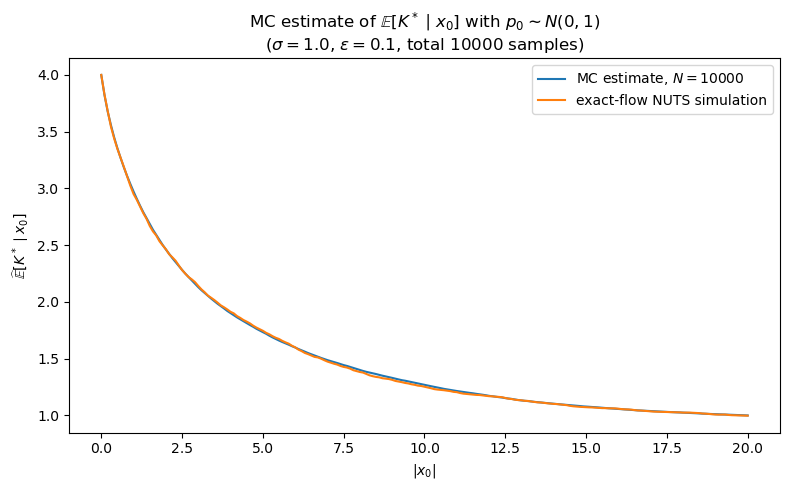

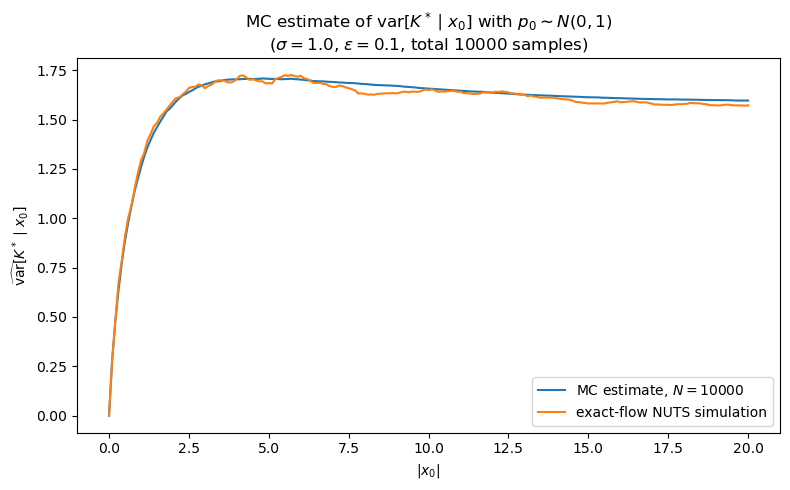

In [14]:
# Comparison: expectation and variance

plt.figure(figsize=(8, 5))
plt.plot(x0_abs_vals, EK_vals, label=rf"MC estimate, $N={N}$")
plt.plot(x0_abs_vals, EK_sim, label="exact-flow NUTS simulation")
plt.xlabel(r"$|x_0|$")
plt.ylabel(r"$\widehat{\mathbb{E}}[K^*\mid x_0]$")
plt.title(r"MC estimate of $\mathbb{E}[K^*\mid x_0]$ with $p_0\sim N(0,1)$"
          "\n"
          rf"($\sigma={sigma}$, $\epsilon={epsilon}$, total {N} samples)")
plt.legend()
plt.tight_layout()
plt.show()


plt.figure(figsize=(8, 5))
plt.plot(x0_abs_vals, varK_vals, label=rf"MC estimate, $N={N}$")
plt.plot(x0_abs_vals, varK_sim, label="exact-flow NUTS simulation")
plt.xlabel(r"$|x_0|$")
plt.ylabel(r"$\widehat{\mathrm{var}}[K^*\mid x_0]$")
plt.title(r"MC estimate of $\mathrm{var}[K^*\mid x_0]$ with $p_0\sim N(0,1)$"
          "\n"
          rf"($\sigma={sigma}$, $\epsilon={epsilon}$, total {N} samples)")
plt.legend()
plt.tight_layout()
plt.show()

## Investigation of the primary U-turn time, secondary U-turn time and observed U-turn time

The **primary U-turn time** $t_1 = \min(|t^-|, t^+) = \min\left(\sigma \left(\frac{\pi}{2} - \theta\right), \sigma \left(\frac{\pi}{2} + \theta\right)\right)$; the **secondary U-turn time** $t_2 = \max(|t^-|, t^+) = \max\left(\sigma \left(\frac{\pi}{2} - \theta\right), \sigma \left(\frac{\pi}{2} + \theta\right)\right)$, $\theta = \arctan(x_0/\sigma p_0)$. Their expectations are shown as

$$
\begin{aligned}
\mathbb{E}(t_1 \mid x_0) &= \int\left[\min\left(\sigma \left(\frac{\pi}{2} - \theta\right), \sigma \left(\frac{\pi}{2} + \theta\right)\right)\right]\varphi(p_0)dp_0 \approx \frac{1}{N}\sum_{n=1}^N \left[\min\left(\sigma \left(\frac{\pi}{2} - \theta^{(n)}\right), \sigma \left(\frac{\pi}{2} + \theta^{(n)}\right)\right)\right]\\
\mathbb{E}(t_2 \mid x_0) &= \int\left[\max\left(\sigma \left(\frac{\pi}{2} - \theta\right), \sigma \left(\frac{\pi}{2} + \theta\right)\right)\right]\varphi(p_0)dp_0 \approx \frac{1}{N}\sum_{n=1}^N \left[\max\left(\sigma \left(\frac{\pi}{2} - \theta^{(n)}\right), \sigma \left(\frac{\pi}{2} + \theta^{(n)}\right)\right)\right]\\
\end{aligned}
$$
that $\theta^{(n)} = \arctan(x_0/\sigma p_0^{(n)})$ for $p_0^{(n)}\sim \mathcal{N}(0,1)$.

The analytical expression of the **observed U-turn time** $T*$ with $\mathbb{E}(T^* \mid x_0)$:

$$
\begin{aligned}
\mathbb{E}(T^* \mid x_0) &= \int\left[\tau^+ P^+(x_0, p_0) + |\tau^-|P^-(x_0, p_0)\right]\varphi(p_0)dp_0\\
&\approx \frac{1}{N}\sum_{n=1}^N \left[\tau^+ P^+(x_0, p_0^{(n)}) + |\tau^-|P^-(x_0, p_0^{(n)})\right], \quad p_0^{(n)} \sim \mathcal{N}(0,1)
\end{aligned}
$$

In [15]:
# ============================================================
# Conditional probabilities P_+ and P_-
# ============================================================

def conditional_P_plus_minus(x0, p0, sigma=1.0, epsilon=0.1, max_k=100):
    """
    Compute P_+(x0,p0) and P_-(x0,p0) analytically.

    P_+ = probability that the first observed U-turn is forward.
    P_- = probability that the first observed U-turn is backward.
    """
    k_minus, k_plus = sign_run_lengths(
        x0, p0, sigma=sigma, epsilon=epsilon, tol=1e-12
    )

    # Initialize probabilitites and k
    P_plus = 0.0
    P_minus = 0.0
    k = 0

    while True:
        # Define l_k and u_k for I_k = [l_k, u_k]
        l_k = max(2**k - 1 + k_minus, 0)
        u_k = min(k_plus, 2**k - 1)

        # If no valid retained tree after k doublings, later terms vanish.
        if l_k > u_k:
            break

        # Count F_k:
        # valid values such that next forward doubling crosses m_plus + 1
        forward_threshold = k_plus + 1 - 2**k
        F_k = max(0, u_k - max(l_k, forward_threshold) + 1)

        # Count B_k:
        # valid values such that next backward doubling crosses m_minus + 1
        backward_upper = 2**(k+1) + k_minus - 2
        B_k = max(0, min(u_k, backward_upper) - l_k + 1)

        P_plus += (2 ** (-k - 1)) * F_k
        P_minus += (2 ** (-k - 1)) * B_k

        k += 1

        if k > max_k:
            raise RuntimeError("Loop did not terminate. You may need to change max_k.")

    return P_plus, P_minus


# ============================================================
# Conditional expectation E[T* | x0, p0]
# ============================================================

def conditional_expected_T_obs(x0, p0, sigma=1.0, epsilon=0.1, max_k=100):
    """
    Compute E[T* | x0, p0] analytically.

    T* = tau^+ I(observed forward) - tau^- I(observed backward),
    where
        tau^+ = (k^+ + 1) epsilon
        tau^- = (k^- - 1) epsilon
    """
    k_minus, k_plus = sign_run_lengths(
        x0, p0, sigma=sigma, epsilon=epsilon, tol=1e-12
    )

    P_plus, P_minus = conditional_P_plus_minus(
        x0, p0, sigma=sigma, epsilon=epsilon, max_k=max_k
    )

    tau_plus = (k_plus + 1) * epsilon
    tau_minus = (k_minus - 1) * epsilon

    cond_expected_uturn_time_obs = tau_plus * P_plus - tau_minus * P_minus

    return cond_expected_uturn_time_obs


# ============================================================
# Monte Carlo estimator for E[T* | x0]
# ============================================================

def mc_estimate_ET_obs_given_x0(x0, N, sigma=1.0, epsilon=0.1, seed=0, max_k=100):
    """
    Monte Carlo estimate of E[T* | x0].

    Samples p0 ~ N(0,1), then computes the analytic conditional
    expectation E[T* | x0,p0], and averages.
    """
    rng = np.random.default_rng(seed)
    p0_samples = rng.normal(0.0, 1.0, size=N)

    cond_vals = np.empty(N)

    for i, p0 in enumerate(p0_samples):
        cond_expected_uturn_time_obs = conditional_expected_T_obs(
            x0=x0,
            p0=p0,
            sigma=sigma,
            epsilon=epsilon,
            max_k=max_k
        )

        cond_vals[i] = cond_expected_uturn_time_obs

    estimate = cond_vals.mean()
    se = float(cond_vals.std(ddof=1) / np.sqrt(N))

    return estimate, se, cond_vals

x0 = 1.0  # Example x0 value to estimate E[T* | x0]
estimate, se, _ = mc_estimate_ET_obs_given_x0(x0, N=N, sigma=sigma, epsilon=epsilon, seed=seed, max_k=100)
print(f"MC estimate for E[T* | x0={x0}], N={N}: {estimate:.6f}")
print(f"Monte Carlo SE: {se:.6f}")
print(f"Approx. 95% MC interval: [{estimate - 1.96*se:.6f}, {estimate + 1.96*se:.6f}]")

MC estimate for E[T* | x0=1.0], N=10000: 0.951718
Monte Carlo SE: 0.004040
Approx. 95% MC interval: [0.943799, 0.959637]


In [16]:
def compute_primary_uturn_time(x0, sigma=1.0, n_reps=10000, seed=0):
    """
    Compute the primary U-turn time T* for given x0, using the exact Hamiltonian flow, by MC estimate.
    This is the time of the first U-turn along the exact Hamiltonian trajectory starting from (x0, p0),
    where p0 is sampled from N(0,1).
    """

    rng = np.random.default_rng(seed)
    p0_samples = rng.normal(0.0, 1.0, size=n_reps)

    primary_uturn_time = 0.0  # Initialize the primary U-turn time

    for p0 in p0_samples:
        theta = np.arctan(x0 / (sigma * p0))  # Initial angle for this p0
        primary_uturn_time += min(sigma * (np.pi/2 - theta), sigma * (np.pi/2 + theta))  # Time to the first U-turn for this p0

    return primary_uturn_time / n_reps

def compute_secondary_uturn_time(x0, sigma=1.0, n_reps=10000, seed=0):
    """
    Compute the secondary U-turn time T** for given x0, using the exact Hamiltonian flow, by MC estimate.
    This is the time of the second U-turn along the exact Hamiltonian trajectory starting from (x0, p0),
    where p0 is sampled from N(0,1).
    """

    rng = np.random.default_rng(seed)
    p0_samples = rng.normal(0.0, 1.0, size=n_reps)

    secondary_uturn_time = 0.0  # Initialize the secondary U-turn time

    for p0 in p0_samples:
        theta = np.arctan(x0 / (sigma * p0))  # Initial angle for this p0
        secondary_uturn_time += max(sigma * (np.pi/2 - theta), sigma * (np.pi/2 + theta))  # Time to the second U-turn for this p0

    return secondary_uturn_time / n_reps

def estimate_uturn_time_by_simulation(x0, sigma=1.0, epsilon=0.1, n_rep=10000, seed=0):
    """
    Estimate T* by simulating exact-flow NUTS trees.

    Each repetition:
      1. samples p0 ~ N(0,1),
      2. builds one random NUTS tree,
      3. records T*.
    """
    rng = np.random.default_rng(seed)
    sampler = ExactFlowNUTS_1D_Gaussian(sigma=sigma, epsilon=epsilon, rng=rng)

    # K_values = np.empty(n_rep, dtype=float)
    uturn_time = np.empty(n_rep, dtype=float)

    for i in range(n_rep):
        p0 = rng.normal(0.0, 1.0)
        out = sampler.one_tree(x0=x0, p0=p0, max_depth=20, return_sample=False)
        # K_values[i] = out["K_star"]
        uturn_time[i] = out["T_obs"]

    uturn_time_observed = uturn_time.mean()

    return uturn_time_observed

# ============================================================
# Example: one fixed x0
# ============================================================

sigma = 1.0
epsilon = 0.1
x0_example = 1.0

uturn_time_observed = estimate_uturn_time_by_simulation(
    x0=x0_example,
    sigma=sigma,
    epsilon=epsilon,
    n_rep=N,
    seed=0
)

print(f"Exact-flow NUTS simulation estimate for E[T* | x0={x0_example}]")
print(f"Mean estimate = {uturn_time_observed:.6f}")

Exact-flow NUTS simulation estimate for E[T* | x0=1.0]
Mean estimate = 0.951390


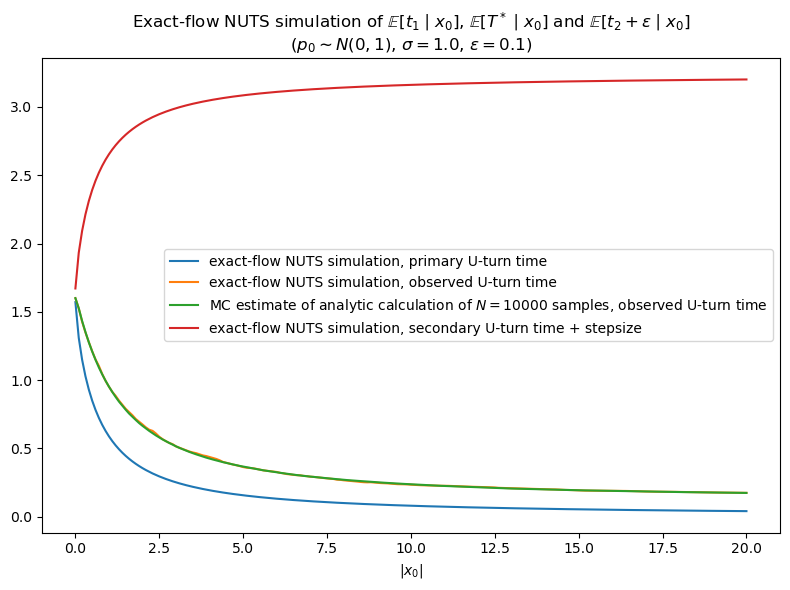

In [17]:
t1_sim = []
t2_sim = []
T_obs_sim = []
T_obs_analytic = []

# Use different seeds for each x0, or use seed offset.
for i, x in enumerate(x0_abs_vals):
    primary_uturn_time = compute_primary_uturn_time(float(x), sigma=sigma, n_reps=N, seed=seed)
    t1_sim.append(primary_uturn_time)

    # The observed U-turn time from the exact-flow NUTS simulation
    uturn_time_observed_sim = estimate_uturn_time_by_simulation(
        x0=float(x),
        sigma=sigma,
        epsilon=epsilon,
        n_rep=N,
        seed=seed
    )
    T_obs_sim.append(uturn_time_observed_sim)

    # The observed U-turn time from the analytic calculation
    estimate, _, _ = mc_estimate_ET_obs_given_x0(float(x), N=N, sigma=sigma, epsilon=epsilon, seed=seed, max_k=100)
    T_obs_analytic.append(estimate)

    secondary_uturn_time = compute_secondary_uturn_time(float(x), sigma=sigma, n_reps=N, seed=seed)
    t2_sim.append(secondary_uturn_time)

t1_sim = np.array(t1_sim)
T_obs_sim = np.array(T_obs_sim)
T_obs_analytic = np.array(T_obs_analytic)
t2_sim = np.array(t2_sim)

plt.figure(figsize=(8, 6))
plt.plot(x0_abs_vals, t1_sim, label="exact-flow NUTS simulation, primary U-turn time")
plt.plot(x0_abs_vals, T_obs_sim, label="exact-flow NUTS simulation, observed U-turn time")
plt.plot(x0_abs_vals, T_obs_analytic, label=rf"MC estimate of analytic calculation of $N={N}$ samples, observed U-turn time")
plt.plot(x0_abs_vals, t2_sim + epsilon, label="exact-flow NUTS simulation, secondary U-turn time + stepsize")
plt.xlabel(r"$|x_0|$")
# plt.ylabel(r"$\widehat{\mathbb{E}}[t_1\mid x_0]$")
plt.title(
    r"Exact-flow NUTS simulation of $\mathbb{E}[t_1\mid x_0]$, $\mathbb{E}[T^*\mid x_0]$ and $\mathbb{E}[t_2 + \epsilon \mid x_0]$"
    "\n"
    rf"($p_0\sim N(0,1)$, $\sigma={sigma}$, $\epsilon={epsilon}$)"
) 
plt.legend()
plt.tight_layout()
plt.show()

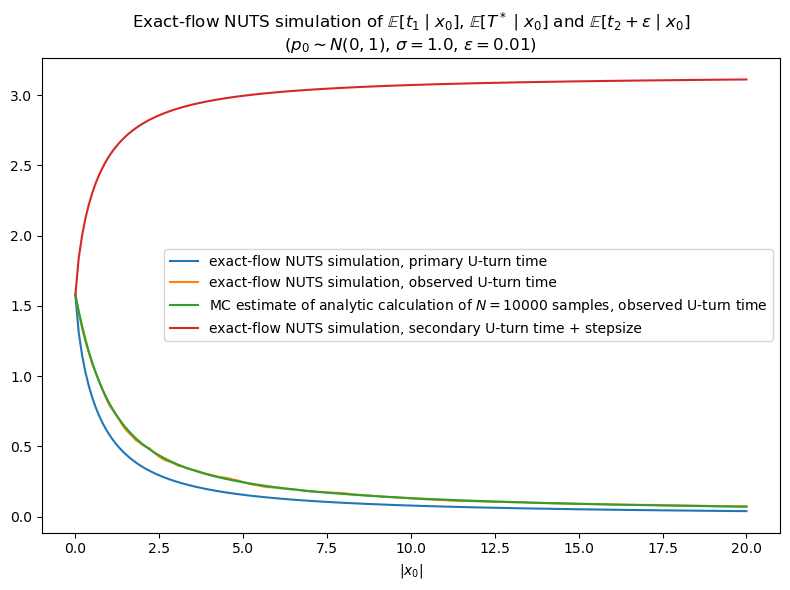

In [18]:
t1_sim = []
t2_sim = []
T_obs_sim = []
T_obs_analytic = []

# Use different seeds for each x0, or use seed offset.
for i, x in enumerate(x0_abs_vals):
    primary_uturn_time = compute_primary_uturn_time(float(x), sigma=sigma, n_reps=N, seed=seed)
    t1_sim.append(primary_uturn_time)

    # The observed U-turn time from the exact-flow NUTS simulation
    uturn_time_observed_sim = estimate_uturn_time_by_simulation(
        x0=float(x),
        sigma=sigma,
        epsilon=0.01,  # a smaller stepsize tends to give observed U-turn times closer to the primary U-turn time
        n_rep=N,
        seed=seed
    )
    T_obs_sim.append(uturn_time_observed_sim)

    # The observed U-turn time from the analytic calculation
    estimate, _, _ = mc_estimate_ET_obs_given_x0(float(x), N=N, sigma=sigma, epsilon=0.01, seed=seed, max_k=100)
    T_obs_analytic.append(estimate)

    secondary_uturn_time = compute_secondary_uturn_time(float(x), sigma=sigma, n_reps=N, seed=seed)
    t2_sim.append(secondary_uturn_time)

t1_sim = np.array(t1_sim)
T_obs_sim = np.array(T_obs_sim)
T_obs_analytic = np.array(T_obs_analytic)
t2_sim = np.array(t2_sim)

plt.figure(figsize=(8, 6))
plt.plot(x0_abs_vals, t1_sim, label="exact-flow NUTS simulation, primary U-turn time")
plt.plot(x0_abs_vals, T_obs_sim, label="exact-flow NUTS simulation, observed U-turn time")
plt.plot(x0_abs_vals, T_obs_analytic, label=rf"MC estimate of analytic calculation of $N={N}$ samples, observed U-turn time")
plt.plot(x0_abs_vals, t2_sim + 0.01, label="exact-flow NUTS simulation, secondary U-turn time + stepsize")
plt.xlabel(r"$|x_0|$")
# plt.ylabel(r"$\widehat{\mathbb{E}}[t_1\mid x_0]$")
plt.title(
    r"Exact-flow NUTS simulation of $\mathbb{E}[t_1\mid x_0]$, $\mathbb{E}[T^*\mid x_0]$ and $\mathbb{E}[t_2 + \epsilon \mid x_0]$"
    "\n"
    rf"($p_0\sim N(0,1)$, $\sigma={sigma}$, $\epsilon={0.01}$)"
) 
plt.legend()
plt.tight_layout()
plt.show()

## Trajectory

In [21]:
def plot_one_NUTS_trajectory(x0, sigma=1.0, epsilon=0.1, seed=0, max_depth=20):
    """
    Generate one exact-flow NUTS tree from x0, then plot x(t), p(t),
    phase trajectory, and the 3D trajectory (x, p, t)
    for all visited grid points in the final candidate set.
    """

    rng = np.random.default_rng(seed)
    sampler = ExactFlowNUTS_1D_Gaussian(sigma=sigma, epsilon=epsilon, rng=rng)

    # Sample initial momentum once, as in 1-jump NUTS
    p0 = rng.normal(0.0, 1.0)

    # Build one NUTS tree
    out = sampler.one_tree(
        x0=x0,
        p0=p0,
        max_depth=max_depth,
        return_sample=True
    )

    # Extract visited indices
    C_indices = np.array(out["C_indices"], dtype=int)

    # Sort them for plotting in time order
    C_indices_sorted = np.sort(C_indices)

    # Convert grid indices to time
    t_vals = C_indices_sorted * epsilon

    # Compute exact-flow states at those times
    x_vals = []
    p_vals = []

    for n in C_indices_sorted:
        x_n, p_n = sampler.state(n, x0, p0)
        x_vals.append(x_n)
        p_vals.append(p_n)

    x_vals = np.array(x_vals)
    p_vals = np.array(p_vals)

    print(f"Initial x0 = {x0:.4f}")
    print(f"Initial p0 = {p0:.4f}")
    print(f"K* = {out['K_star']}")
    print(f"Final tree indices: [{out['left']}, {out['right']}]")
    print(f"The observed U-turn time T_obs = {out['T_obs']:.4f}, at index {out['observed_uturn_index']} for the next doubling.")
    print(f"Chosen sample index = {out['chosen_index']}")
    print(f"Chosen x = {out['x_sample']:.4f}, chosen p = {out['p_sample']:.4f}")

    # ------------------------------------------------------------
    # Plot x(t)
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(t_vals, x_vals, marker="o")
    plt.axvline(0, linestyle="--", linewidth=1)  # initial position at time 0
    plt.xlabel(r"$t=n\epsilon$")
    plt.ylabel(r"$x(t)$")
    plt.title("Exact-flow NUTS trajectory: position against time")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot p(t)
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(t_vals, p_vals, marker="o")
    # By our theorem we should not observe any sign change in p(t)
    # for all visited points in the final candidate set.
    plt.axhline(0, linewidth=1)  # detect sign changes in momentum
    plt.axvline(0, linestyle="--", linewidth=1)  # initial momentum at time 0
    plt.xlabel(r"$t=n\epsilon$")
    plt.ylabel(r"$p(t)$")
    plt.title("Exact-flow NUTS trajectory: momentum against time")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Phase plot x(t), p(t)
    # ------------------------------------------------------------
    plt.figure(figsize=(6, 6))
    plt.plot(x_vals, p_vals, marker="o")
    plt.scatter([x0], [p0], s=80, color="red", label="initial state")
    plt.scatter(
        [out["x_sample"]],
        [out["p_sample"]],
        s=80,
        color="orange",
        label="chosen sample"
    )
    plt.xlabel(r"$x(t)$")
    plt.ylabel(r"$p(t)$")
    plt.title("Exact-flow NUTS trajectory in phase space")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # 3D plot: (x, p, t)
    # ------------------------------------------------------------
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(
        x_vals,
        p_vals,
        t_vals,
        marker="o",
        label="NUTS retained states"
    )

    # Initial state
    ax.scatter(
        [x0],
        [p0],
        [0.0],
        s=80,
        color="red",
        label="initial state"
    )

    # Chosen sample
    ax.scatter(
        [out["x_sample"]],
        [out["p_sample"]],
        [out["chosen_index"] * epsilon],
        s=80,
        color="orange",
        label="chosen sample"
    )

    ax.set_xlabel(r"$x(t)$")
    ax.set_ylabel(r"$p(t)$")
    ax.set_zlabel(r"$t=n\epsilon$")
    ax.set_title(r"Exact-flow NUTS trajectory in 3D: $(x(t),p(t),t)$")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return out, t_vals, x_vals, p_vals

Initial x0 = 1.0000
Initial p0 = 0.1891
K* = 3
Final tree indices: [-7, 0]
The observed U-turn time T_obs = 0.2000, at index 2 for the next doubling.
Chosen sample index = -2
Chosen x = 0.9425, chosen p = 0.3840


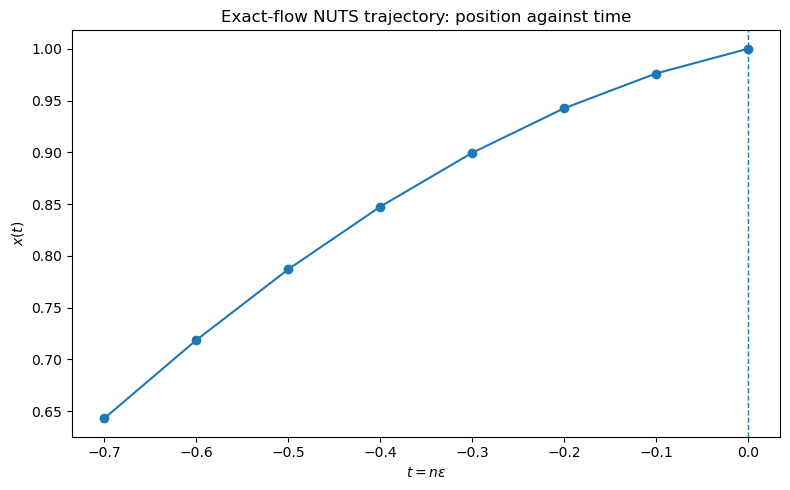

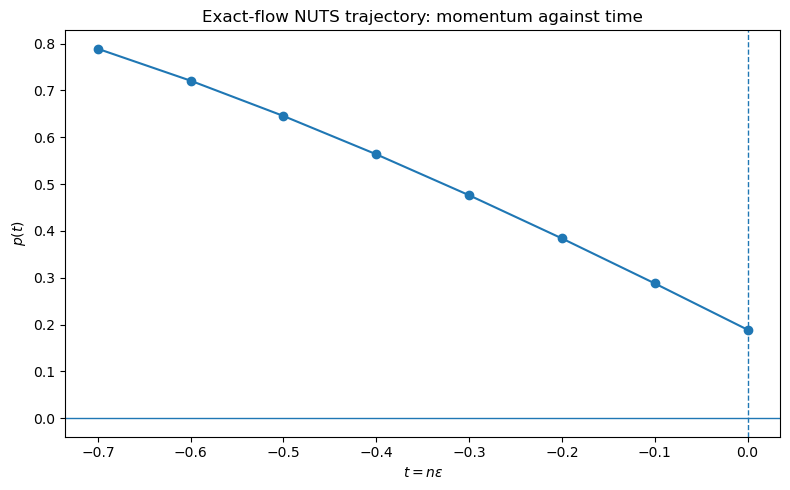

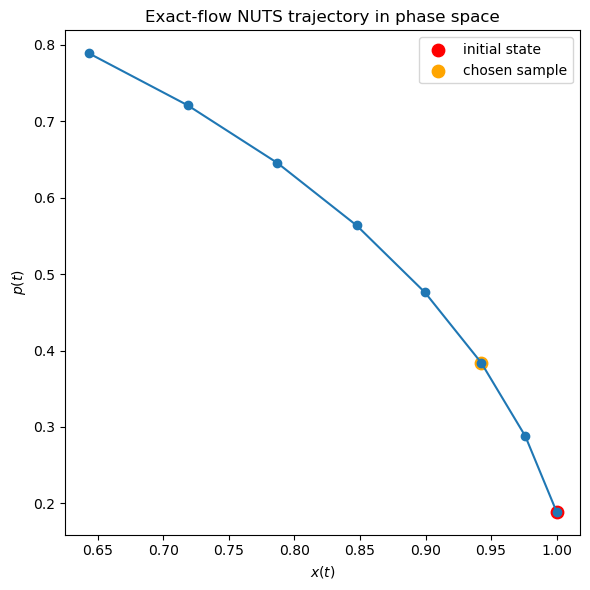

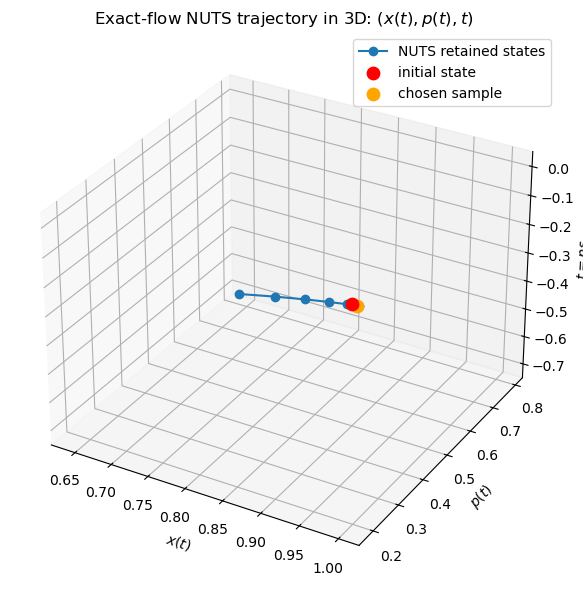

In [23]:
sigma = 1.0
epsilon = 0.1
x0_example = 1.0

out, t_vals, x_vals, p_vals = plot_one_NUTS_trajectory(
    x0=x0_example,
    sigma=sigma,
    epsilon=epsilon,
    seed=2,
    max_depth=20
)

# Exponential target distribution

In [ ]:
def exp_momentum(k, x0, p0, lam=1.0, epsilon=0.1):
    """
    Exact reflected Hamiltonian flow for the momentum at time t = k * epsilon
    for Exp(lambda) target on x > 0.

    Hamiltonian:
        H(x,p) = lambda * x + p^2 / 2

    Reflected periodic flow:
        m = sqrt(p0^2 + 2 lambda x0)
        T = 2m / lambda
        s(t) = ((m - p0) / lambda + t) mod T
        p(t) = m - lambda s(t)
    """
    t = k * epsilon

    m = np.sqrt(p0**2 + 2.0 * lam * x0)
    T = 2.0 * m / lam  # period of the reflected flow

    s0 = (m - p0) / lam  # initial "phase" of the reflected flow
    s = np.mod(s0 + t, T)  # current "phase" at time t, modulo the period

    p_t = m - lam * s  # momentum at time t according to the reflected flow

    return p_t

def sign_of(v, tol=1e-12):
    """Check the sign of a value, with a tolerance."""
    if abs(v) <= tol:
        return 0
    return 1 if v > 0 else -1

def exp_sign_run_lengths(x0, p0, lam=1.0, epsilon=0.1, tol=1e-12):
    """
    Analytical same-sign run [k_minus, k_plus] around 0
    for the reflected Exp(lambda) Hamiltonian flow.

    Returns
    -------
    k_minus : int
        Leftmost grid index with same sign as p0.
    k_plus : int
        Rightmost grid index with same sign as p0.
    """
    s0 = sign_of(p0, tol=tol)  # record the initial sign of the momentum p0

    if s0 == 0:
        return 0, 0

    m = np.sqrt(p0**2 + 2.0 * lam * x0)

    # Determine the time intervals where p(t) has the same sign as p0, which depends on sign of p0
    if p0 > 0:
        # p(t) > 0 for t in ((p0 - m)/lam, p0/lam)
        t_left = (p0 - m) / lam
        t_right = p0 / lam
        # Compute the corresponding grid indices for the left and right boundaries of the same-sign interval
        k_plus = int(np.floor(t_right / epsilon))
        k_minus = int(np.ceil(t_left / epsilon))
    else:
        # p(t) < 0 for t in (p0/lam, (p0 + m)/lam)
        t_left = p0 / lam
        t_right = (p0 + m) / lam
        # Compute the corresponding grid indices for the left and right boundaries of the same-sign interval
        k_plus = int(np.floor(t_right / epsilon))
        k_minus = int(np.ceil(t_left / epsilon))

    return k_minus, k_plus

In [38]:
def survival_prob_K_ge_k(k, k_minus, k_plus):
    """Compute the survival probability q_k = P(K* >= k | x0, p0) for a given k."""
    if k == 0:
        return 1.0
    n = 2**k
    lower = max(0, n - 1 + k_minus)
    upper = min(n - 1, k_plus)
    count = max(0, upper - lower + 1)
    return count / n

def expected_K_star_conditional_exp(x0, p0, lam=1.0, epsilon=0.1):
    """
    Compute E[K* | x0, p0] for Exp(lambda) using survival probabilities.
    The expectation can be computed as the sum of survival probabilities, but depends on the sign of p0.
    """

    # Determine the k_minus and k_plus w.r.t sign of p0
    k_minus, k_plus = exp_sign_run_lengths(
        x0=x0,
        p0=p0,
        lam=lam,
        epsilon=epsilon
    )

    total = 0.0  # Initialize the total expected value
    k = 1

    while True:
        q = survival_prob_K_ge_k(k, k_minus, k_plus)
        total += q
        if q == 0:  # once we observe one survival probability is zero, then we can stop as the rest will also be zero
            break
        k += 1
        if k > 500:  # safety check to prevent infinite loops in case of unexpected behavior
            break

    return total

def second_moment_K_star_conditional_exp(x0, p0, lam=1.0, epsilon=0.1):
    """
    Compute E[K*^2 | x0, p0] for Exp(lambda) using survival probabilities.
    The second moment can be computed as the sum of (2k-1) * q_k, but depends on the sign of p0.
    """

    # Determine the k_minus and k_plus w.r.t sign of p0
    k_minus, k_plus = exp_sign_run_lengths(
        x0=x0,
        p0=p0,
        lam=lam,
        epsilon=epsilon
    )

    total = 0.0  # Initialize the total variance
    k = 1

    while True:
        q = survival_prob_K_ge_k(k, k_minus, k_plus)
        total += (2*k-1) * q
        if q == 0:  # once we observe one survial probability is zero, then we can stop as the rest will also be zero
            break
        k += 1  # update k
        if k > 500:  # safety check to prevent infinite loops in case of unexpected behavior
            break

    return total

def var_K_star_conditional_exp(x0, p0, lam=1.0, epsilon=0.1):
    """Compute var[K* | x0, p0] for Exp(lambda) using the survival probabilities."""
    second_moment = second_moment_K_star_conditional_exp(x0, p0, lam=lam, epsilon=epsilon)
    expecation = expected_K_star_conditional_exp(x0, p0, lam=lam, epsilon=epsilon)
    return second_moment - expecation**2

In [39]:
def exp_mc_estimate_EK_given_x0(x0, N, lam, epsilon=0.1, seed=0):
    """MC estimate of E[K* | x0] by sampling p0 from N(0,1) and averaging E[K* | x0, p0]."""
    rng = np.random.default_rng(seed)
    p0_samples = rng.normal(0.0, 1.0, size=N)
    values = np.array([expected_K_star_conditional_exp(x0, float(p), lam=lam, epsilon=epsilon)
                       for p in p0_samples])
    estimate = float(values.mean())
    se = float(values.std(ddof=1) / np.sqrt(N))  # Standard error of the mean
    return estimate, se, values

x0 = 1.0  # Example x0 value to estimate E[K* | x0]
lam = 1.0  # Example lambda value for the Exp(lambda) target
estimate, se, _ = exp_mc_estimate_EK_given_x0(x0, N=N, lam=lam, epsilon=epsilon, seed=seed)
print(f"MC estimate for E[K* | x0={x0}], N={N}: {estimate:.6f}")
print(f"Monte Carlo SE: {se:.6f}")
print(f"Approx. 95% MC interval: [{estimate - 1.96*se:.6f}, {estimate + 1.96*se:.6f}]")

MC estimate for E[K* | x0=1.0], N=10000: 2.623106
Monte Carlo SE: 0.006419
Approx. 95% MC interval: [2.610524, 2.635688]


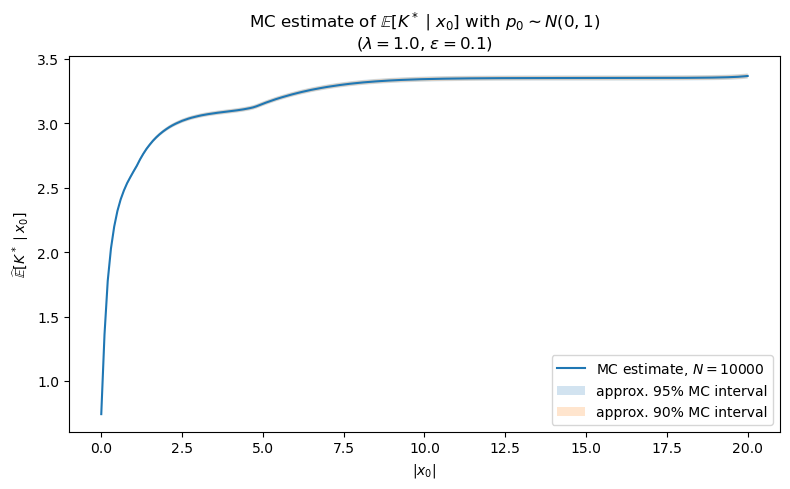

In [51]:
EK_vals = []
SE_vals = []
for x0 in x0_abs_vals_exp:
    est_x, se_x, _ = exp_mc_estimate_EK_given_x0(float(x0), N=N, lam=lam, epsilon=epsilon, seed=seed)
    EK_vals.append(est_x)
    SE_vals.append(se_x)

# Convert lists to numpy arrays for easier plotting
EK_vals = np.array(EK_vals)
SE_vals = np.array(SE_vals)

plt.figure(figsize=(8, 5))
plt.plot(x0_abs_vals, EK_vals, label=rf"MC estimate, $N={N}$")
plt.fill_between(x0_abs_vals, EK_vals - 1.96*SE_vals, EK_vals + 1.96*SE_vals, alpha=0.2,
                 label="approx. 95% MC interval")
plt.fill_between(x0_abs_vals, EK_vals - 1.645*SE_vals, EK_vals + 1.645*SE_vals, alpha=0.2,
                 label="approx. 90% MC interval")
plt.xlabel(r"$|x_0|$")
plt.ylabel(r"$\widehat{\mathbb{E}}[K^*\mid x_0]$")
plt.title(r"MC estimate of $\mathbb{E}[K^*\mid x_0]$ with $p_0\sim N(0, 1)$"
          "\n"
          rf"($\lambda={lam}$, $\epsilon={epsilon}$)")
plt.legend()
plt.tight_layout()
plt.show()

Similarly we can also use MC estimate on $\mathrm{var}(K^* \mid x_0)$.

As before, we also check whether the above analytical result for the expression of $\mathbb{E}(K^*\mid x_0)$ is true. This needs us to run a real NUTS simulator for once (under the exact Hamiltonian flow in this case) and check the graph of $\mathbb{E}(K^* \mid x_0)$ against $|x_0|$.


In [42]:
class ExactFlowNUTS_1D_Exponential(ExactFlowNUTS_1D_Gaussian):
    """
    Exact-flow NUTS tree simulator for the 1D Exponential target Exp(lambda).

    Target:
        pi(x) = lambda exp(-lambda x), x > 0.

    Hamiltonian:
        H(x,p) = lambda x + p^2 / 2.

    The exact flow is reflected at x = 0. Therefore x(t) is periodic and
    piecewise quadratic, while p(t) is periodic and piecewise linear.

    We record K* = number of successful completed full-tree doublings before stopping.
    """

    def __init__(self, lam=1.0, epsilon=0.1, rng=None):
        self.lam = lam
        self.epsilon = epsilon
        self.rng = np.random.default_rng() if rng is None else rng

    def state(self, n, x0, p0):
        """
        Exact reflected Hamiltonian state at grid index n, i.e. time t = n epsilon.

        For Exp(lambda), define

            m = sqrt(p0^2 + 2 lambda x0),
            T = 2m / lambda,
            s0 = (m - p0) / lambda,
            s(t) = (s0 + t) mod T.

        Then

            x(t) = m s(t) - lambda s(t)^2 / 2,
            p(t) = m - lambda s(t).

        This automatically enforces x(t) >= 0.
        """
        if x0 <= 0:
            raise ValueError("For Exp(lambda), x0 must be positive.")
        if self.lam <= 0:
            raise ValueError("lambda must be positive.")

        t = n * self.epsilon
        lam = self.lam

        m = np.sqrt(p0**2 + 2.0 * lam * x0)
        T = 2.0 * m / lam

        s0 = (m - p0) / lam
        s = np.mod(s0 + t, T)

        x_n = m * s - 0.5 * lam * s**2
        p_n = m - lam * s

        return x_n, p_n

In [43]:
# ============================================================
# Monte Carlo estimator using the exact-flow NUTS simulator
# ============================================================

def estimate_EK_by_simulation_exp(x0, lam=1.0, epsilon=0.1, n_rep=10000, seed=0):
    """
    Estimate E[K* | x0] by simulating exact-flow NUTS trees.

    Each repetition:
      1. samples p0 ~ N(0,1),
      2. builds one random NUTS tree,
      3. records K*.
    """
    rng = np.random.default_rng(seed)
    sampler = ExactFlowNUTS_1D_Exponential(lam=lam, epsilon=epsilon, rng=rng)

    K_values = np.empty(n_rep, dtype=float)

    for i in range(n_rep):
        p0 = rng.normal(0.0, 1.0)
        out = sampler.one_tree(x0=x0, p0=p0, max_depth=20, return_sample=False)
        K_values[i] = out["K_star"]

    mean_esti = K_values.mean()
    var_esti = K_values.var(ddof=1)  # sample variance
    se = K_values.std(ddof=1) / np.sqrt(n_rep)

    return mean_esti, var_esti, se, K_values


# ============================================================
# Example: one fixed x0
# ============================================================

lam = 1.0
epsilon = 0.1
x0_example = 1.0

mean_esti, var_esti, se, K_values = estimate_EK_by_simulation_exp(
    x0=x0_example,
    lam=lam,
    epsilon=epsilon,
    n_rep=N,
    seed=0
)

print(f"Exact-flow NUTS simulation estimate for E[K* | x0={x0_example}]")
print(f"Mean estimate = {mean_esti:.6f}, variance estimate = {var_esti:.6f}")
print(f"Monte Carlo SE = {se:.6f}")
print(f"approx. 95% MC interval = [{mean_esti - 1.96*se:.6f}, {mean_esti + 1.96*se:.6f}]")

Exact-flow NUTS simulation estimate for E[K* | x0=1.0]
Mean estimate = 2.617200, variance estimate = 0.821146
Monte Carlo SE = 0.009062
approx. 95% MC interval = [2.599439, 2.634961]


In [ ]:
# ============================================================
# Plot E[K* | x0] against |x0| (6.5 min on PC)
# ============================================================

EK_sim = []
varK_sim = []
SE_sim = []

# Use different seeds for each x0, or use seed offset.
for i, x in enumerate(x0_abs_vals_exp):
    mean_esti, var_esti, se, _ = estimate_EK_by_simulation_exp(
        x0=float(x),
        lam=lam,
        epsilon=epsilon,
        n_rep=N,
        seed=seed
    )
    EK_sim.append(mean_esti)
    varK_sim.append(var_esti)
    SE_sim.append(se)

EK_sim = np.array(EK_sim)
varK_sim = np.array(varK_sim)
SE_sim = np.array(SE_sim)

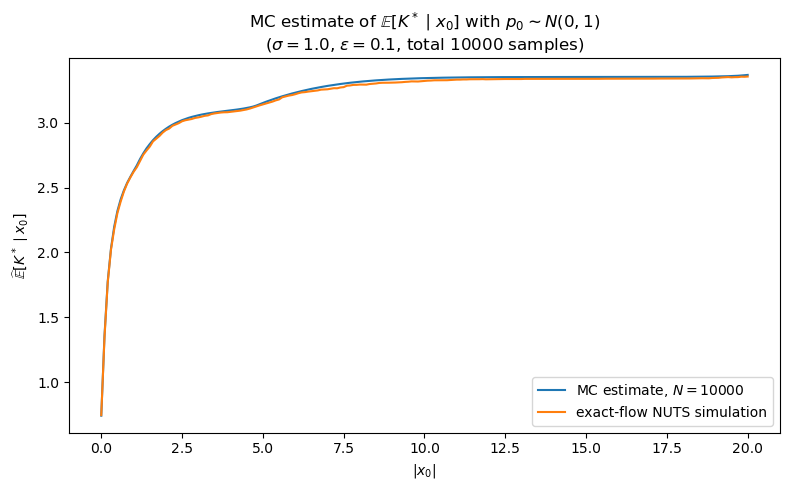

In [53]:
# Comparison: expectation and variance

plt.figure(figsize=(8, 5))
plt.plot(x0_abs_vals, EK_vals, label=rf"MC estimate, $N={N}$")
plt.plot(x0_abs_vals, EK_sim, label="exact-flow NUTS simulation")
plt.xlabel(r"$|x_0|$")
plt.ylabel(r"$\widehat{\mathbb{E}}[K^*\mid x_0]$")
plt.title(r"MC estimate of $\mathbb{E}[K^*\mid x_0]$ with $p_0\sim N(0,1)$"
          "\n"
          rf"($\sigma={sigma}$, $\epsilon={epsilon}$, total {N} samples)")
plt.legend() 
plt.tight_layout()
plt.show()


# plt.figure(figsize=(8, 5))
# plt.plot(x0_abs_vals, varK_vals, label=rf"MC estimate, $N={N}$")
# plt.plot(x0_abs_vals, varK_sim, label="exact-flow NUTS simulation")
# plt.xlabel(r"$|x_0|$")
# plt.ylabel(r"$\widehat{\mathrm{var}}[K^*\mid x_0]$")
# plt.title(r"MC estimate of $\mathrm{var}[K^*\mid x_0]$ with $p_0\sim N(0,1)$"
#           "\n"
#           rf"($\sigma={sigma}$, $\epsilon={epsilon}$, total {N} samples)")
# plt.legend()
# plt.tight_layout()
# plt.show()

## Trajectory - Exponential

In [54]:
def plot_one_NUTS_trajectory_exp(x0, lam=1.0, epsilon=0.1, seed=0, max_depth=20):
    """
    Generate one exact-flow NUTS tree from x0, then plot x(t), p(t),
    phase trajectory, and the 3D trajectory (x, p, t)
    for all visited grid points in the final candidate set.
    """

    rng = np.random.default_rng(seed)
    sampler = ExactFlowNUTS_1D_Exponential(lam=lam, epsilon=epsilon, rng=rng)

    # Sample initial momentum once, as in 1-jump NUTS
    p0 = rng.normal(0.0, 1.0)

    # Build one NUTS tree
    out = sampler.one_tree(
        x0=x0,
        p0=p0,
        max_depth=max_depth,
        return_sample=True
    )

    # Extract visited indices
    C_indices = np.array(out["C_indices"], dtype=int)

    # Sort them for plotting in time order
    C_indices_sorted = np.sort(C_indices)

    # Convert grid indices to time
    t_vals = C_indices_sorted * epsilon

    # Compute exact-flow states at those times
    x_vals = []
    p_vals = []

    for n in C_indices_sorted:
        x_n, p_n = sampler.state(n, x0, p0)
        x_vals.append(x_n)
        p_vals.append(p_n)

    x_vals = np.array(x_vals)
    p_vals = np.array(p_vals)

    print(f"Initial x0 = {x0:.4f}")
    print(f"Initial p0 = {p0:.4f}")
    print(f"K* = {out['K_star']}")
    print(f"Final tree indices: [{out['left']}, {out['right']}]")
    print(f"Chosen sample index = {out['chosen_index']}")
    print(f"Chosen x = {out['x_sample']:.4f}, chosen p = {out['p_sample']:.4f}")

    # ------------------------------------------------------------
    # Plot x(t)
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(t_vals, x_vals, marker="o")
    plt.axvline(0, linestyle="--", linewidth=1)  # initial position at time 0
    plt.xlabel(r"$t=n\epsilon$")
    plt.ylabel(r"$x(t)$")
    plt.title("Exact-flow NUTS trajectory: position against time")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Plot p(t)
    # ------------------------------------------------------------
    plt.figure(figsize=(8, 5))
    plt.plot(t_vals, p_vals, marker="o")
    # By our theorem we should not observe any sign change in p(t)
    # for all visited points in the final candidate set.
    plt.axhline(0, linewidth=1)  # detect sign changes in momentum
    plt.axvline(0, linestyle="--", linewidth=1)  # initial momentum at time 0
    plt.xlabel(r"$t=n\epsilon$")
    plt.ylabel(r"$p(t)$")
    plt.title("Exact-flow NUTS trajectory: momentum against time")
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # Phase plot x(t), p(t)
    # ------------------------------------------------------------
    plt.figure(figsize=(6, 6))
    plt.plot(x_vals, p_vals, marker="o")
    plt.scatter([x0], [p0], s=80, color="red", label="initial state")
    plt.scatter(
        [out["x_sample"]],
        [out["p_sample"]],
        s=80,
        color="orange",
        label="chosen sample"
    )
    plt.xlabel(r"$x(t)$")
    plt.ylabel(r"$p(t)$")
    plt.title("Exact-flow NUTS trajectory in phase space")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ------------------------------------------------------------
    # 3D plot: (x, p, t)
    # ------------------------------------------------------------
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")

    ax.plot(
        x_vals,
        p_vals,
        t_vals,
        marker="o",
        label="NUTS retained states"
    )

    # Initial state
    ax.scatter(
        [x0],
        [p0],
        [0.0],
        s=80,
        color="red",
        label="initial state"
    )

    # Chosen sample
    ax.scatter(
        [out["x_sample"]],
        [out["p_sample"]],
        [out["chosen_index"] * epsilon],
        s=80,
        color="orange",
        label="chosen sample"
    )

    ax.set_xlabel(r"$x(t)$")
    ax.set_ylabel(r"$p(t)$")
    ax.set_zlabel(r"$t=n\epsilon$")
    ax.set_title(r"Exact-flow NUTS trajectory in 3D: $(x(t),p(t),t)$")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return out, t_vals, x_vals, p_vals

Initial x0 = 1.0000
Initial p0 = 0.1257
K* = 3
Final tree indices: [-6, 1]
Chosen sample index = 0
Chosen x = 1.0000, chosen p = 0.1257


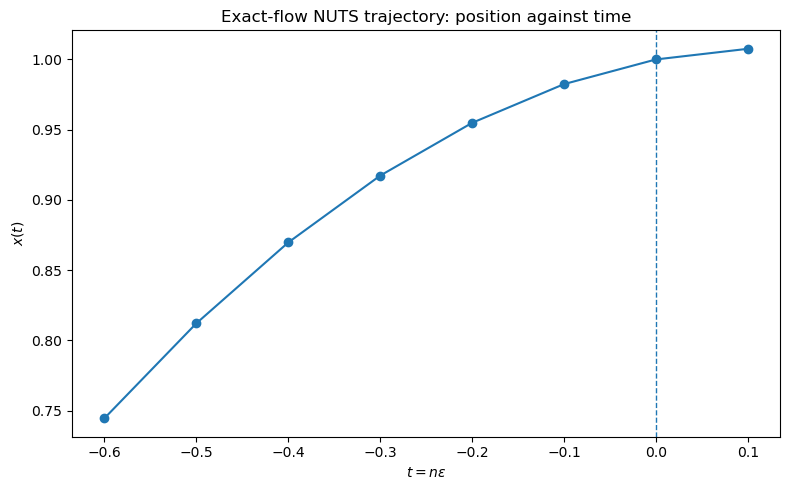

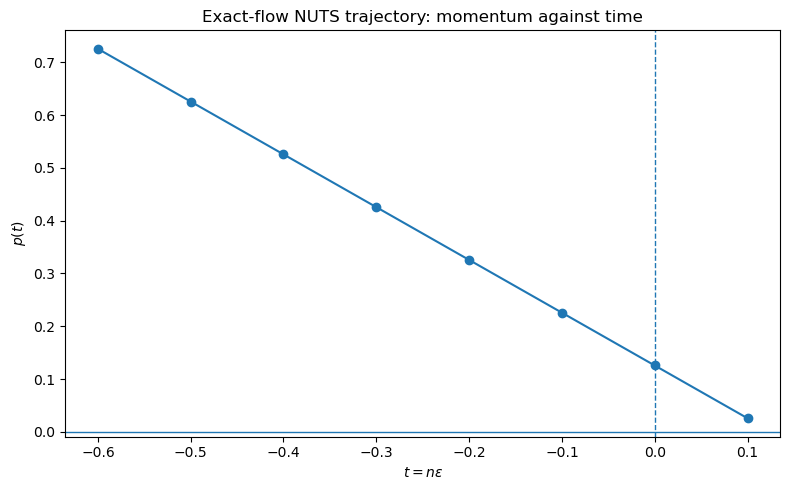

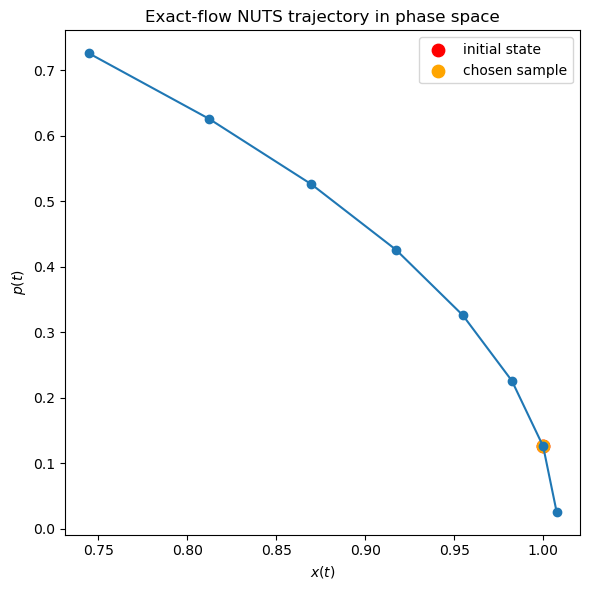

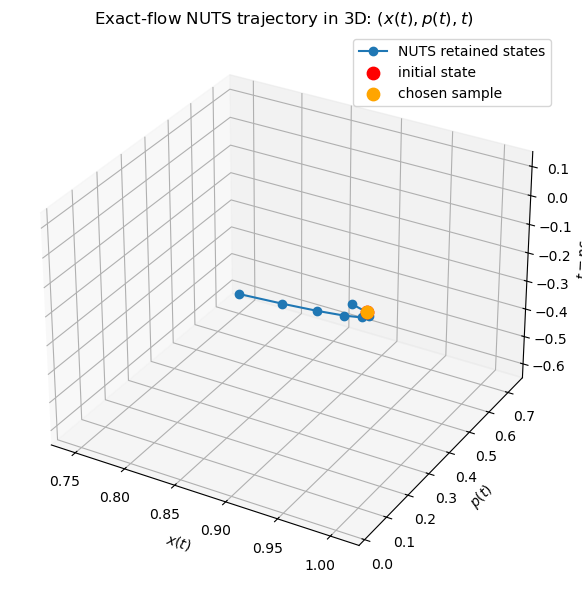

In [57]:
lam = 1.0
epsilon = 0.1
x0_example = 1.0

out, t_vals, x_vals, p_vals = plot_one_NUTS_trajectory_exp(
    x0=x0_example,
    lam=lam,
    epsilon=epsilon,
    seed=0,
    max_depth=20
)

# Leapfrog flow analysis for the U-turn time?

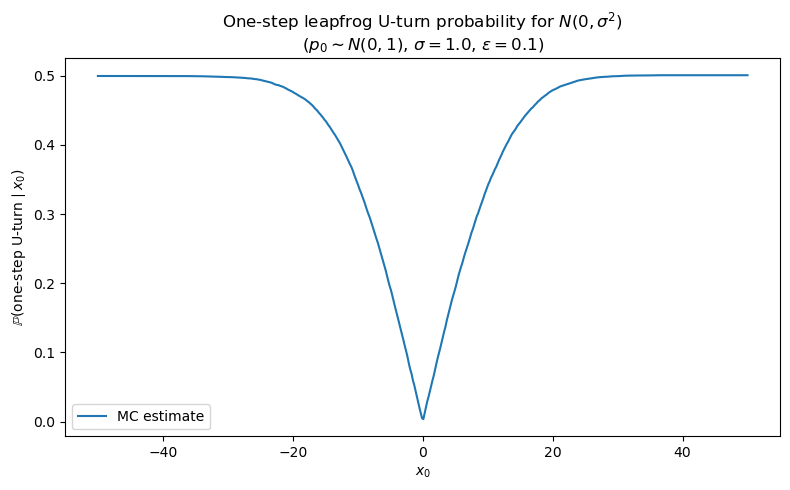

In [75]:
def leapfrog_gaussian_1d(x0, p0, sigma=1.0, epsilon=0.1):
    """
    One leapfrog step for target N(0, sigma^2) with unit mass.
    """
    # half momentum update
    p_half = p0 - 0.5 * epsilon * x0 / sigma**2

    # full position update
    x1 = x0 + epsilon * p_half

    # another half momentum update
    p1 = p_half - 0.5 * epsilon * x1 / sigma**2

    return x1, p1


def one_step_uturn_leapfrog(x0, p0, sigma=1.0, epsilon=0.1):
    """
    Check the one-step NUTS U-turn condition after one leapfrog step.
    """
    x1, p1 = leapfrog_gaussian_1d(x0, p0, sigma=sigma, epsilon=epsilon)

    dx = x1 - x0

    h0 = dx * p0
    h1 = dx * p1

    uturn = (h0 < 0.0) or (h1 < 0.0)

    return uturn, h0, h1, x1, p1

def estimate_one_step_uturn_prob(x0, sigma=1.0, epsilon=0.1, M=10000, seed=0):
    rng = np.random.default_rng(seed)
    p0_samples = rng.normal(0.0, 1.0, size=M)

    indicators = np.empty(M, dtype=float)

    for i, p0 in enumerate(p0_samples):
        uturn, _, _, _, _ = one_step_uturn_leapfrog(
            x0=x0,
            p0=p0,
            sigma=sigma,
            epsilon=epsilon
        )
        indicators[i] = float(uturn)

    prob_hat = indicators.mean()
    se = indicators.std(ddof=1) / np.sqrt(M)

    return prob_hat, se


sigma = 1.0
epsilon = 0.1

x_vals = np.linspace(-50, 50, 500)

prob_vals = []
se_vals = []

for x in x_vals:
    prob, se = estimate_one_step_uturn_prob(
        x0=float(x),
        sigma=sigma,
        epsilon=epsilon,
        seed=123
    )
    prob_vals.append(prob)
    se_vals.append(se)

prob_vals = np.array(prob_vals)
se_vals = np.array(se_vals)

plt.figure(figsize=(8, 5))
plt.plot(x_vals, prob_vals, label="MC estimate")
# plt.fill_between(
#     x_vals,
#     prob_vals - 1.96 * se_vals,
#     prob_vals + 1.96 * se_vals,
#     alpha=0.2,
#     label="approx. 95% MC interval"
# )
plt.xlabel(r"$x_0$")
plt.ylabel(r"$\mathbb{P}(\mathrm{one\text{-}step\ U\text{-}turn}\mid x_0)$")
plt.title(
    r"One-step leapfrog U-turn probability for $N(0,\sigma^2)$"
    "\n"
    rf"($p_0\sim N(0,1)$, $\sigma={sigma}$, $\epsilon={epsilon}$)"
)
plt.legend()
plt.tight_layout()
plt.show()